In [1]:
import pandas as pd

forecast = pd.read_csv(
    "../data/processed/forecast_30_days.csv"
)

forecast.head()

,ds,yhat
0,2010-12-01,24355.090268
1,2010-12-02,31316.088857
2,2010-12-03,19857.210247
3,2010-12-05,10886.000829
4,2010-12-06,22171.674093


In [2]:
forecast["SafetyStock"] = (
    forecast["yhat"] * 0.20
)

forecast["LeadTime"] = 7

forecast["ReorderQty"] = (
    forecast["yhat"] * forecast["LeadTime"]
    + forecast["SafetyStock"]
)

forecast.head()

,ds,yhat,SafetyStock,LeadTime,ReorderQty
0,2010-12-01,24355.090268,4871.018054,7,175356.649929
1,2010-12-02,31316.088857,6263.217771,7,225475.839772
2,2010-12-03,19857.210247,3971.442049,7,142971.913779
3,2010-12-05,10886.000829,2177.200166,7,78379.205971
4,2010-12-06,22171.674093,4434.334819,7,159636.053467


In [3]:
forecast.to_csv(
    "../data/processed/inventory_recommendations.csv",
    index=False
)

print("Inventory recommendations saved")

Inventory recommendations saved


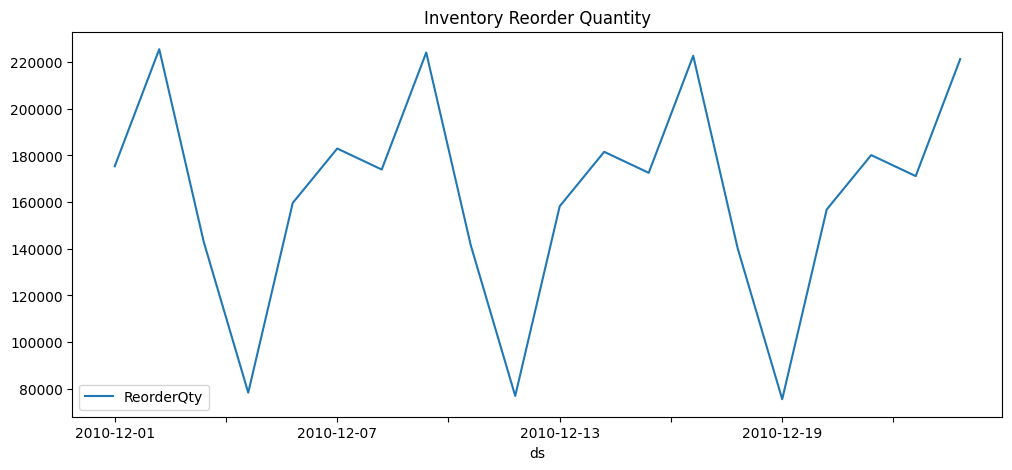

In [4]:
import matplotlib.pyplot as plt

forecast.head(20).plot(
    x="ds",
    y="ReorderQty",
    figsize=(12,5)
)

plt.title("Inventory Reorder Quantity")
plt.show()